# PHISHING DETECTION SYSTEM
A machine learning system to detect phishing URLs using GBC, LSTM, Ensemble modeling, SHAP explainability, and VirusTotal threat intelligence.


## Imports

In [53]:
import re
import math
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import whois
import dns.resolver
import requests
import shap
 
from datetime import datetime, timezone
from urllib.parse import urlparse
from dotenv import load_dotenv
 
import tldextract
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
 
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
 
# Load API key
load_dotenv(dotenv_path=r'C:\Users\Spoorthy\Desktop\Project\.env')
VT_API_KEY = os.getenv("VT_API_KEY")
 
print("All imports loaded successfully!")

All imports loaded successfully!


## Load Datasets

In [3]:
 
# Kaggle dataset (pre-extracted features)
df_kaggle = pd.read_csv('data/phishing.csv')
df_kaggle = df_kaggle.drop(columns=['Index'])
 
# Kaggle dataset with raw URLs
df_urls = pd.read_csv('data/dataset_phishing.csv')
 
# PhishTank dataset
df_phish = pd.read_csv('data/verified_online.csv')
df_phish = df_phish[['url']].copy()
df_phish['label'] = 1
 
print(f"Kaggle dataset     : {df_kaggle.shape}")
print(f"URL dataset        : {df_urls.shape}")
print(f"PhishTank dataset  : {df_phish.shape}")
print(f"\nURL dataset labels :")
print(df_urls['status'].value_counts())

Kaggle dataset     : (11054, 31)
URL dataset        : (11430, 89)
PhishTank dataset  : (58489, 2)

URL dataset labels :
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


## Lexical Feature Extractor

In [5]:
def calculate_entropy(text):
    if not text:
        return 0
    freq = {}
    for c in text:
        freq[c] = freq.get(c, 0) + 1
    entropy = 0
    for count in freq.values():
        p = count / len(text)
        entropy -= p * math.log2(p)
    return round(entropy, 4)
 
 
def extract_lexical_features(url):
    parsed = urlparse(url)
    extracted = tldextract.extract(url)
 
    domain = extracted.domain
    subdomain = extracted.subdomain
    path = parsed.path
    full_url = url
 
    return {
        'url_length'            : len(full_url),
        'domain_length'         : len(domain),
        'path_length'           : len(path),
        'num_dots'              : full_url.count('.'),
        'num_hyphens'           : full_url.count('-'),
        'num_underscores'       : full_url.count('_'),
        'num_slashes'           : full_url.count('/'),
        'num_at'                : full_url.count('@'),
        'num_digits'            : sum(c.isdigit() for c in full_url),
        'num_special_chars'     : len(re.findall(r'[^a-zA-Z0-9]', full_url)),
        'has_ip'                : 1 if re.match(r'http[s]?://\d+\.\d+\.\d+\.\d+', full_url) else 0,
        'has_https'             : 1 if parsed.scheme == 'https' else 0,
        'has_at_symbol'         : 1 if '@' in full_url else 0,
        'has_double_slash'      : 1 if '//' in path else 0,
        'has_hyphen_in_domain'  : 1 if '-' in domain else 0,
        'domain_entropy'        : calculate_entropy(domain),
        'subdomain_entropy'     : calculate_entropy(subdomain),
        'num_subdomains'        : len(subdomain.split('.')) if subdomain else 0
    }

## Whois Feature Extractor

In [7]:
def extract_whois_features(url):
    extracted = tldextract.extract(url)
    domain = extracted.domain + '.' + extracted.suffix
 
    try:
        w = whois.whois(domain)
        now = datetime.now(timezone.utc)
 
        creation_date = w.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]
        if creation_date:
            if creation_date.tzinfo is None:
                creation_date = creation_date.replace(tzinfo=timezone.utc)
            age_days = (now - creation_date).days
        else:
            age_days = -1
 
        expiration_date = w.expiration_date
        if isinstance(expiration_date, list):
            expiration_date = expiration_date[0]
        if expiration_date:
            if expiration_date.tzinfo is None:
                expiration_date = expiration_date.replace(tzinfo=timezone.utc)
            expiration_days = (expiration_date - now).days
        else:
            expiration_days = -1
 
        registrar = w.registrar if w.registrar else "unknown"
 
        return {
            'domain_age_days' : age_days,
            'expiration_days' : expiration_days,
            'registrar'       : registrar,
            'whois_available' : 1
        }
 
    except Exception:
        return {
            'domain_age_days' : -1,
            'expiration_days' : -1,
            'registrar'       : 'unknown',
            'whois_available' : 0
        }

## DNS Feature Extractor

In [9]:
def extract_dns_features(url):
    extracted = tldextract.extract(url)
    domain = extracted.domain + '.' + extracted.suffix
 
    try:
        answers = dns.resolver.resolve(domain, 'A')
        has_dns = 1
        ip_count = len(answers)
    except Exception:
        has_dns = 0
        ip_count = 0
 
    try:
        dns.resolver.resolve(domain, 'MX')
        has_mx = 1
    except Exception:
        has_mx = 0
 
    try:
        ns_records = dns.resolver.resolve(domain, 'NS')
        has_ns = 1
        ns_count = len(ns_records)
    except Exception:
        has_ns = 0
        ns_count = 0
 
    return {
        'has_dns'      : has_dns,
        'ip_count'     : ip_count,
        'has_mx_record': has_mx,
        'has_ns_record': has_ns,
        'ns_count'     : ns_count
    }

## Unified Feature Extractor

In [11]:
def extract_features(url):
    lexical = extract_lexical_features(url)
    whois_f = extract_whois_features(url)
    dns_f   = extract_dns_features(url)
 
    whois_f.pop('registrar', None)
 
    features = {}
    features.update(lexical)
    features.update(whois_f)
    features.update(dns_f)
 
    return features
 
 
# Quick test
test_urls = [
    "https://www.google.com",
    "http://paypal-secure-login.com/verify/account",
    "http://192.168.1.1/admin/login.php"
]
 
for url in test_urls:
    features = extract_features(url)
    print(f"URL: {url}")
    print(f"  Total features: {len(features)}")
    for k, v in features.items():
        print(f"  {k}: {v}")
    print("-" * 50)

URL: https://www.google.com
  Total features: 26
  url_length: 22
  domain_length: 6
  path_length: 0
  num_dots: 2
  num_hyphens: 0
  num_underscores: 0
  num_slashes: 2
  num_at: 0
  num_digits: 0
  num_special_chars: 5
  has_ip: 0
  has_https: 1
  has_at_symbol: 0
  has_double_slash: 0
  has_hyphen_in_domain: 0
  domain_entropy: 1.9183
  subdomain_entropy: 0.0
  num_subdomains: 1
  domain_age_days: 10453
  expiration_days: 868
  whois_available: 1
  has_dns: 1
  ip_count: 1
  has_mx_record: 1
  has_ns_record: 1
  ns_count: 4
--------------------------------------------------
URL: http://paypal-secure-login.com/verify/account
  Total features: 26
  url_length: 45
  domain_length: 19
  path_length: 15
  num_dots: 1
  num_hyphens: 2
  num_underscores: 0
  num_slashes: 4
  num_at: 0
  num_digits: 0
  num_special_chars: 8
  has_ip: 0
  has_https: 0
  has_at_symbol: 0
  has_double_slash: 0
  has_hyphen_in_domain: 1
  domain_entropy: 3.7216
  subdomain_entropy: 0
  num_subdomains: 0
  doma

## GBC Training (Kaggle Dataset)

Training GBC on Kaggle dataset...

--- GBC Results (Kaggle Dataset) ---
Accuracy  : 0.9647
Precision : 0.9623
Recall    : 0.9748
F1 Score  : 0.9685
AUC-ROC   : 0.9947


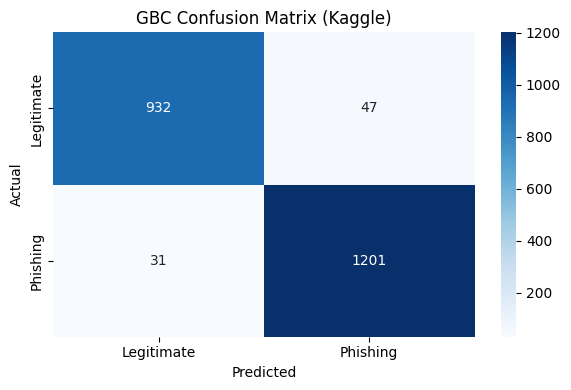

In [13]:
X_kaggle = df_kaggle.drop(columns=['class'])
y_kaggle = df_kaggle['class']
 
X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(
    X_kaggle, y_kaggle, test_size=0.2, random_state=42, stratify=y_kaggle
)
 
gbc = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
 
print("Training GBC on Kaggle dataset...")
gbc.fit(X_tr_k, y_tr_k)
 
y_pred_k = gbc.predict(X_te_k)
y_prob_k = gbc.predict_proba(X_te_k)[:, 1]
 
print("\n--- GBC Results (Kaggle Dataset) ---")
print(f"Accuracy  : {accuracy_score(y_te_k, y_pred_k):.4f}")
print(f"Precision : {precision_score(y_te_k, y_pred_k, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_te_k, y_pred_k, pos_label=1):.4f}")
print(f"F1 Score  : {f1_score(y_te_k, y_pred_k, pos_label=1):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_te_k, y_prob_k):.4f}")
 
cm = confusion_matrix(y_te_k, y_pred_k)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('GBC Confusion Matrix (Kaggle)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/gbc_confusion_matrix.png')
plt.show()

## GBC Training (URL Dataset)

In [15]:
X_new = df_urls.drop(columns=['url', 'status'])
y_new = np.array([1 if s == 'phishing' else 0 for s in df_urls['status']])
 
X_tr_new, X_te_new, y_tr_new, y_te_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)
 
gbc_new = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
 
print("Training GBC on URL dataset...")
gbc_new.fit(X_tr_new, y_tr_new)
 
y_pred_new = gbc_new.predict(X_te_new)
y_prob_new = gbc_new.predict_proba(X_te_new)[:, 1]
 
print("\n--- GBC Results (URL Dataset) ---")
print(f"Accuracy  : {accuracy_score(y_te_new, y_pred_new):.4f}")
print(f"Precision : {precision_score(y_te_new, y_pred_new):.4f}")
print(f"Recall    : {recall_score(y_te_new, y_pred_new):.4f}")
print(f"F1 Score  : {f1_score(y_te_new, y_pred_new):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_te_new, y_prob_new):.4f}")

Training GBC on URL dataset...

--- GBC Results (URL Dataset) ---
Accuracy  : 0.9602
Precision : 0.9574
Recall    : 0.9633
F1 Score  : 0.9603
AUC-ROC   : 0.9930


## LSTM Training

Vocabulary size : 101
Training samples: 9144
Testing samples : 2286


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.5147 - loss: 0.6875 - val_accuracy: 0.5200 - val_loss: 0.6828
Epoch 2/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.5146 - loss: 0.6823 - val_accuracy: 0.5200 - val_loss: 0.6781
Epoch 3/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.5203 - loss: 0.6808 - val_accuracy: 0.5036 - val_loss: 0.6783
Epoch 4/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.5195 - loss: 0.6802 - val_accuracy: 0.5200 - val_loss: 0.6767
Epoch 5/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.5128 - loss: 0.6799 - val_accuracy: 0.5205 - val_loss: 0.6770
Epoch 6/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - accuracy: 0.5126 - loss: 0.6796 - val_accuracy: 0.5205 - val_loss: 0.6766
Epoch 7/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.5180 - loss: 0.6792 - val_accuracy: 0.5205 - val_loss: 0.6764
Epoch 8/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 104ms/step - accura

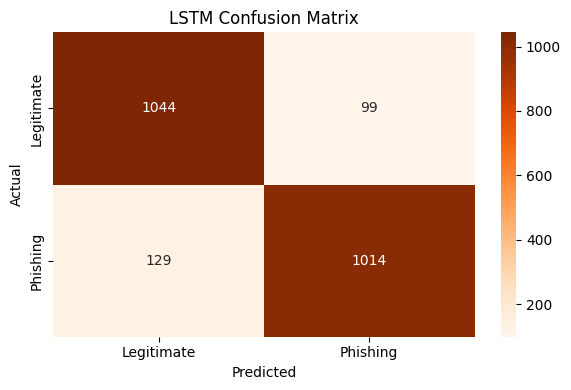

In [17]:
urls   = df_urls['url'].tolist()
labels = [1 if s == 'phishing' else 0 for s in df_urls['status']]
 
# Build character vocabulary
chars    = set(''.join(urls))
char2idx = {char: idx + 1 for idx, char in enumerate(sorted(chars))}
vocab_size = len(char2idx) + 1
max_len    = 200
 
def url_to_sequence(url, char2idx, max_len=200):
    return [char2idx.get(c, 0) for c in url[:max_len]]
 
sequences = [url_to_sequence(url, char2idx) for url in urls]
X_lstm    = pad_sequences(sequences, maxlen=max_len, padding='post')
y_lstm    = np.array(labels)
 
X_tr_lstm, X_te_lstm, y_tr_lstm, y_te_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)
 
print(f"Vocabulary size : {vocab_size}")
print(f"Training samples: {len(X_tr_lstm)}")
print(f"Testing samples : {len(X_te_lstm)}")
 
# Build model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
 
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
 
lstm_model.summary()
 
# Train — 50 epochs total
print("\nTraining LSTM model...")
lstm_model.fit(X_tr_lstm, y_tr_lstm, epochs=50, batch_size=32,
               validation_split=0.2, verbose=1)
print("Training complete!")
 
# Evaluate
y_pred_lstm = (lstm_model.predict(X_te_lstm) > 0.5).astype(int).flatten()
y_prob_lstm = lstm_model.predict(X_te_lstm).flatten()
 
print("\n--- LSTM Results ---")
print(f"Accuracy  : {accuracy_score(y_te_lstm, y_pred_lstm):.4f}")
print(f"Precision : {precision_score(y_te_lstm, y_pred_lstm):.4f}")
print(f"Recall    : {recall_score(y_te_lstm, y_pred_lstm):.4f}")
print(f"F1 Score  : {f1_score(y_te_lstm, y_pred_lstm):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_te_lstm, y_prob_lstm):.4f}")
 
cm = confusion_matrix(y_te_lstm, y_pred_lstm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('LSTM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/lstm_confusion_matrix.png')
plt.show()

## ENSEMBLE

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
--- Ensemble Results ---
Accuracy  : 0.9681
Precision : 0.9660
Recall    : 0.9703
F1 Score  : 0.9681
AUC-ROC   : 0.9924


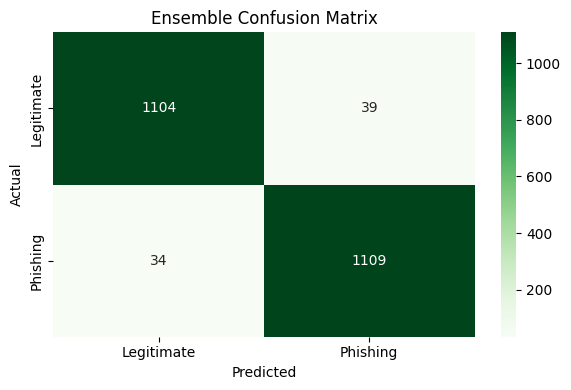

In [19]:
gbc_prob_ens      = gbc_new.predict_proba(X_te_new)[:, 1]
lstm_prob_ens     = lstm_model.predict(X_te_lstm).flatten()
ensemble_prob     = (0.6 * gbc_prob_ens) + (0.4 * lstm_prob_ens)
ensemble_pred     = (ensemble_prob > 0.5).astype(int)
 
print("--- Ensemble Results ---")
print(f"Accuracy  : {accuracy_score(y_te_new, ensemble_pred):.4f}")
print(f"Precision : {precision_score(y_te_new, ensemble_pred):.4f}")
print(f"Recall    : {recall_score(y_te_new, ensemble_pred):.4f}")
print(f"F1 Score  : {f1_score(y_te_new, ensemble_pred):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_te_new, ensemble_prob):.4f}")
 
cm = confusion_matrix(y_te_new, ensemble_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Ensemble Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/ensemble_confusion_matrix.png')
plt.show()

## Save All Models

In [21]:
os.makedirs('models', exist_ok=True)
 
joblib.dump(gbc,                         'models/gbc_model.pkl')
joblib.dump(gbc_new,                     'models/gbc_new_model.pkl')
joblib.dump(X_kaggle.columns.tolist(),   'models/feature_names.pkl')
joblib.dump(X_new.columns.tolist(),      'models/feature_names_new.pkl')
joblib.dump(char2idx,                    'models/char2idx.pkl')
joblib.dump(max_len,                     'models/max_len.pkl')
lstm_model.save('models/lstm_model.keras')
 
print("All models saved:")
print("  models/gbc_model.pkl")
print("  models/gbc_new_model.pkl")
print("  models/lstm_model.keras")
print("  models/char2idx.pkl")
print("  models/max_len.pkl")

All models saved:
  models/gbc_model.pkl
  models/gbc_new_model.pkl
  models/lstm_model.keras
  models/char2idx.pkl
  models/max_len.pkl


## SHAP Explainability

SHAP values shape: (2286, 87)


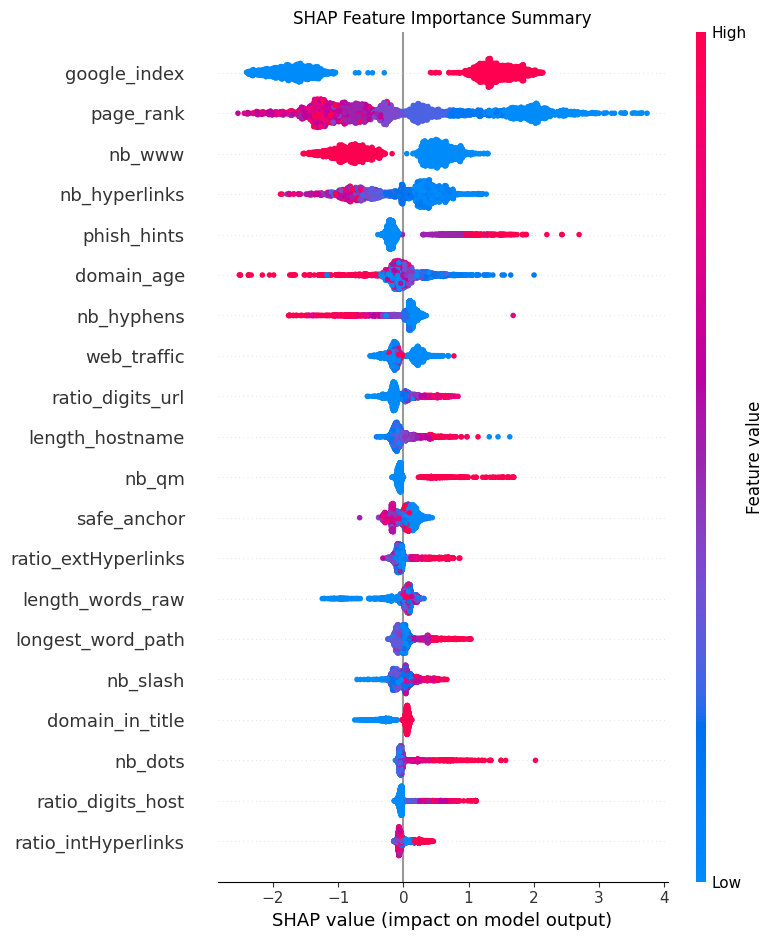

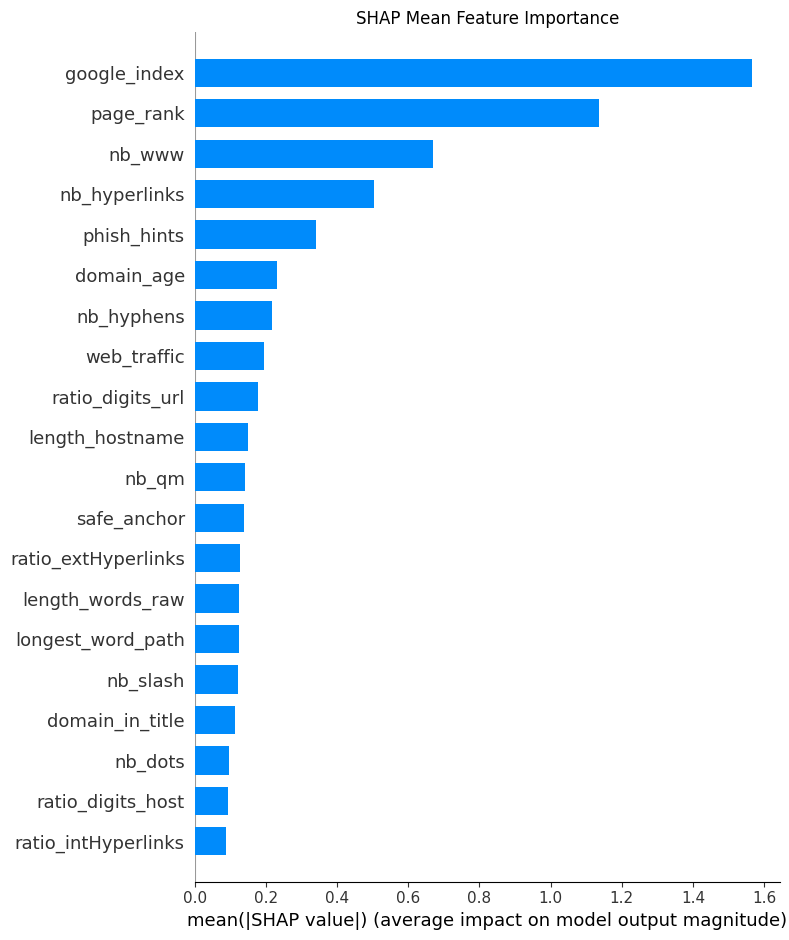

In [23]:
explainer   = shap.TreeExplainer(gbc_new)
shap_values = explainer.shap_values(X_te_new)
feature_names_new = X_new.columns.tolist()
 
print(f"SHAP values shape: {shap_values.shape}")
 
# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_te_new,
                  feature_names=feature_names_new,
                  max_display=20, show=False)
plt.title('SHAP Feature Importance Summary')
plt.tight_layout()
plt.savefig('results/shap_summary_plot.png', bbox_inches='tight')
plt.show()
 
# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_te_new,
                  feature_names=feature_names_new,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Mean Feature Importance')
plt.tight_layout()
plt.savefig('results/shap_bar_plot.png', bbox_inches='tight')
plt.show()

## VirusTotal Integration

In [25]:
def check_virustotal(url):
    headers = {"x-apikey": VT_API_KEY}
 
    try:
        response = requests.post(
            "https://www.virustotal.com/api/v3/urls",
            headers=headers,
            data={"url": url}
        )
 
        if response.status_code != 200:
            return {"error": f"Submission failed: {response.status_code}"}
 
        analysis_id = response.json()["data"]["id"]
        time.sleep(3)
 
        result = requests.get(
            f"https://www.virustotal.com/api/v3/analyses/{analysis_id}",
            headers=headers
        )
 
        if result.status_code != 200:
            return {"error": f"Analysis fetch failed: {result.status_code}"}
 
        stats      = result.json()["data"]["attributes"]["stats"]
        malicious  = stats.get("malicious", 0)
        suspicious = stats.get("suspicious", 0)
        harmless   = stats.get("harmless", 0)
        undetected = stats.get("undetected", 0)
        total      = malicious + suspicious + harmless + undetected
 
        return {
            "malicious"     : malicious,
            "suspicious"    : suspicious,
            "harmless"      : harmless,
            "undetected"    : undetected,
            "total_engines" : total,
            "vt_score"      : round((malicious + suspicious) / total * 100, 2) if total > 0 else 0
        }
 
    except Exception as e:
        return {"error": str(e)}

## Unified Analysis Function

In [27]:
def analyze_url(url, gbc_model, explainer, feature_names):
 
    print(f"\n{'='*60}")
    print(f"Analyzing: {url}")
    print(f"{'='*60}")
 
    # GBC prediction (if URL is in dataset)
    url_data = df_urls[df_urls['url'] == url]
 
    if not url_data.empty:
        X_single  = url_data.drop(columns=['url', 'status'])
        actual    = url_data['status'].values[0]
        gbc_prob  = gbc_model.predict_proba(X_single)[0][1]
        shap_vals = explainer.shap_values(X_single)[0]
        impact    = sorted(zip(feature_names, shap_vals),
                           key=lambda x: abs(x[1]), reverse=True)
        top_5     = impact[:5]
    else:
        gbc_prob = 0.5
        top_5    = []
        actual   = "unknown"
 
    # LSTM prediction
    seq        = url_to_sequence(url, char2idx)
    seq_padded = pad_sequences([seq], maxlen=max_len, padding='post')
    lstm_prob  = float(lstm_model.predict(seq_padded, verbose=0)[0][0])
 
    # VirusTotal
    print("Checking VirusTotal...")
    vt         = check_virustotal(url)
    vt_score   = vt.get("vt_score", 0)
    vt_mal     = vt.get("malicious", 0)
    vt_engines = vt.get("total_engines", 0)
 
    # Combined risk score
    if vt_engines > 0:
        combined = (0.5 * gbc_prob) + (0.3 * lstm_prob) + (0.2 * (vt_score / 100))
    else:
        combined = (0.6 * gbc_prob) + (0.4 * lstm_prob)
 
    risk           = round(combined * 100, 2)
    classification = "PHISHING" if combined > 0.5 else "LEGITIMATE"
 
    print(f"\n--- ANALYSIS REPORT ---")
    print(f"Classification : {classification}")
    print(f"Risk Score     : {risk}%")
    print(f"GBC Confidence : {round(gbc_prob*100, 2)}%")
    print(f"LSTM Confidence: {round(lstm_prob*100, 2)}%")
    print(f"VT Malicious   : {vt_mal}/{vt_engines} engines")
 
    if top_5:
        print(f"\nTop 5 features driving this prediction:")
        for feat, val in top_5:
            direction = "⚠ phishing" if val > 0 else "✓ legitimate"
            print(f"  {feat}: {val:.4f} ({direction})")
 
    print(f"\nActual Label   : {actual}")
 
    return {
        "url"            : url,
        "classification" : classification,
        "risk_score"     : risk,
        "gbc_confidence" : round(gbc_prob * 100, 2),
        "lstm_confidence": round(lstm_prob * 100, 2),
        "vt_malicious"   : vt_mal,
        "vt_engines"     : vt_engines,
        "top_features"   : top_5
    }

## Adversarial Testing

In [71]:
adversarial_urls = [
    "https://bit.ly/3xampleURL",
    "https://tinyurl.com/y4example",
    "http://paypal%2Ecom/login",
    "http://www%2Egoogle%2Ecom",
    "http://paypaI.com/login",
    "http://arnazon.com/products",
    "http://google.com.phishing-site.com/login",
    "http://paypal.com.verify-account.net/secure",
    "https://secure-paypal-login.com/verify",
    "https://amazon-account-verify.com/login",
    "http://www.amazon.com.account-update.suspicious-domain.com/login?ref=amazon",
]

print("ADVERSARIAL TESTING RESULTS")
print("=" * 70)

for url in adversarial_urls:
    seq        = url_to_sequence(url, char2idx)
    seq_padded = pad_sequences([seq], maxlen=max_len, padding='post')
    lstm_prob  = float(lstm_model.predict(seq_padded, verbose=0)[0][0])
    classification = "PHISHING" if lstm_prob > 0.5 else "LEGITIMATE"

    print(f"URL: {url[:60]}")
    print(f"  LSTM: {round(lstm_prob*100, 2)}% → {classification}")
    print()

ADVERSARIAL TESTING RESULTS
URL: https://bit.ly/3xampleURL
  LSTM: 99.74% → PHISHING

URL: https://tinyurl.com/y4example
  LSTM: 97.34% → PHISHING

URL: http://paypal%2Ecom/login
  LSTM: 97.84% → PHISHING

URL: http://www%2Egoogle%2Ecom
  LSTM: 1.64% → LEGITIMATE

URL: http://paypaI.com/login
  LSTM: 78.76% → PHISHING

URL: http://arnazon.com/products
  LSTM: 26.6% → LEGITIMATE

URL: http://google.com.phishing-site.com/login
  LSTM: 99.81% → PHISHING

URL: http://paypal.com.verify-account.net/secure
  LSTM: 99.86% → PHISHING

URL: https://secure-paypal-login.com/verify
  LSTM: 99.75% → PHISHING

URL: https://amazon-account-verify.com/login
  LSTM: 99.82% → PHISHING

URL: http://www.amazon.com.account-update.suspicious-domain.com/l
  LSTM: 99.99% → PHISHING



## Test The Full Pipeline

In [29]:
test_urls = [
    "https://www.youtube.com/watch?v=XszqITK-UEw",
    "http://rapidpaws.com/wp-content/we_transfer/index2.php?email=/"
]
 
for url in test_urls:
    result = analyze_url(url, gbc_new, explainer, feature_names_new)
    time.sleep(2)


Analyzing: https://www.youtube.com/watch?v=XszqITK-UEw
Checking VirusTotal...

--- ANALYSIS REPORT ---
Classification : LEGITIMATE
Risk Score     : 0.93%
GBC Confidence : 1.31%
LSTM Confidence: 0.36%
VT Malicious   : 0/0 engines

Top 5 features driving this prediction:
  google_index: -1.4906 (✓ legitimate)
  page_rank: -0.9473 (✓ legitimate)
  nb_qm: 0.8629 (⚠ phishing)
  nb_www: -0.6490 (✓ legitimate)
  nb_hyperlinks: -0.4557 (✓ legitimate)

Actual Label   : legitimate

Analyzing: http://rapidpaws.com/wp-content/we_transfer/index2.php?email=/
Checking VirusTotal...

--- ANALYSIS REPORT ---
Classification : PHISHING
Risk Score     : 99.51%
GBC Confidence : 99.19%
LSTM Confidence: 99.98%
VT Malicious   : 0/0 engines

Top 5 features driving this prediction:
  phish_hints: 1.3196 (⚠ phishing)
  google_index: 1.1813 (⚠ phishing)
  nb_hyperlinks: 0.4509 (⚠ phishing)
  nb_qm: 0.4397 (⚠ phishing)
  page_rank: 0.3244 (⚠ phishing)

Actual Label   : phishing
